<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [32]:
!pip install pandas

In [33]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [34]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-06-16 03:41:40--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  39.2MB/s    in 3.9s    

2026-06-16 03:41:45 (39.3 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



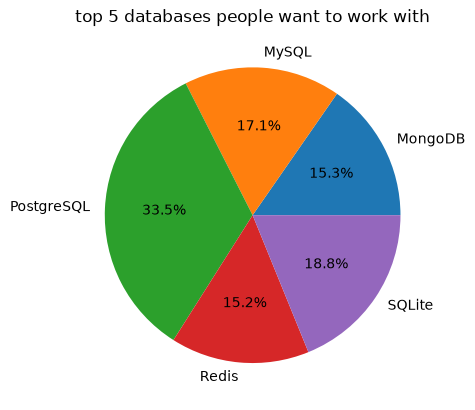

In [35]:
##Write your code here
#df['DatabaseWantToWorkWith'].value_counts()
df_dbww = df.copy()
df_dbww['DatabaseWantToWorkWith'] = df_dbww['DatabaseWantToWorkWith'].str.split(';')
df_dbww = df_dbww.explode('DatabaseWantToWorkWith')
df_dbww['DatabaseWantToWorkWith'] = df_dbww['DatabaseWantToWorkWith'].str.strip()
#df_dbww['DatabaseWantToWorkWith'].value_counts()
dbww = df_dbww.groupby(['DatabaseWantToWorkWith']).size().reset_index(name = 'Frequency')
dbww5 = df_dbww['DatabaseWantToWorkWith'].value_counts().head(5).index
dbww = dbww[dbww['DatabaseWantToWorkWith'].isin(dbww5)]
plt.pie(dbww['Frequency'] , labels = dbww['DatabaseWantToWorkWith'] , autopct = '%1.1f%%')
plt.title('top 5 databases people want to work with')
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



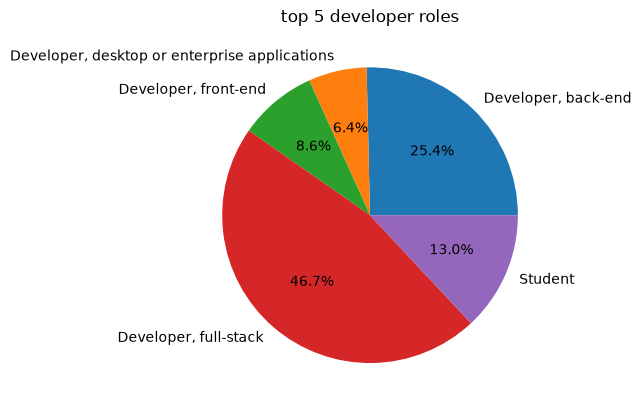

In [36]:
##Write your code here
#df['DevType'].value_counts()
DevType = df.groupby(['DevType']).size().reset_index(name = 'Frequency')
DevType5 = df['DevType'].value_counts().head(5).index
DevType = DevType[DevType['DevType'].isin(DevType5)]
plt.pie(DevType['Frequency'] , labels = DevType['DevType'] , autopct = '%1.1f%%')
plt.title('top 5 developer roles')
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



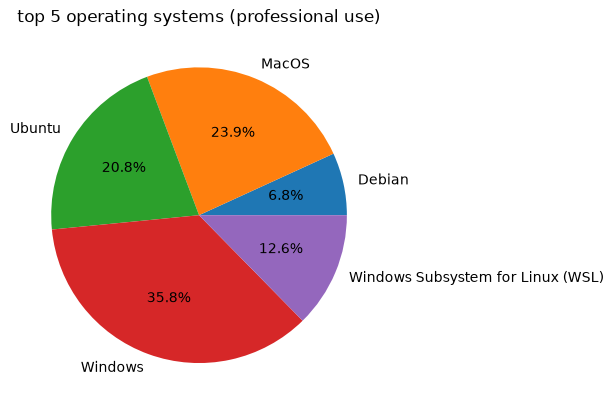

In [37]:
##Write your code here
#[col for col in df.columns if 'Op' in col or 'Sys' in col]
df['OpSysProfessional use'].value_counts()
df_spro = df.copy()
df_spro['OpSysProfessional use'] = df_spro['OpSysProfessional use'].str.split(';')
df_spro = df_spro.explode('OpSysProfessional use')
df_spro['OpSysProfessional use'] = df_spro['OpSysProfessional use'].str.strip()
#df_spro['OpSysProfessional use'].value_counts()
spro = df_spro.groupby(['OpSysProfessional use']).size().reset_index(name = 'Frequency')
spro5 = df_spro['OpSysProfessional use'].value_counts().head(5).index
spro = spro[spro['OpSysProfessional use'].isin(spro5)]
plt.pie(spro['Frequency'] , labels = spro['OpSysProfessional use'] , autopct = '%1.1f%%')
plt.title('top 5 operating systems (professional use)')
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



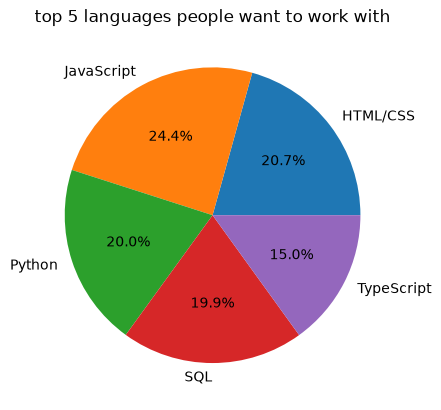

In [38]:
##Write your code here
df_lhww = df.copy()
df_lhww['LanguageHaveWorkedWith'] = df_lhww['LanguageHaveWorkedWith'].str.split(';')
df_lhww = df_lhww.explode('LanguageHaveWorkedWith')
df_lhww['LanguageHaveWorkedWith'] = df_lhww['LanguageHaveWorkedWith'].str.strip()
#df_lhww['LanguageHaveWorkedWith'].value_counts()
lhww = df_lhww.groupby(['LanguageHaveWorkedWith']).size().reset_index(name = 'Frequency')
lhww5 = df_lhww['LanguageHaveWorkedWith'].value_counts().head(5).index
lhww = lhww[lhww['LanguageHaveWorkedWith'].isin(lhww5)]
plt.pie(lhww['Frequency'] , labels = lhww['LanguageHaveWorkedWith'] , autopct = '%1.1f%%')
plt.title('top 5 languages people want to work with')
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



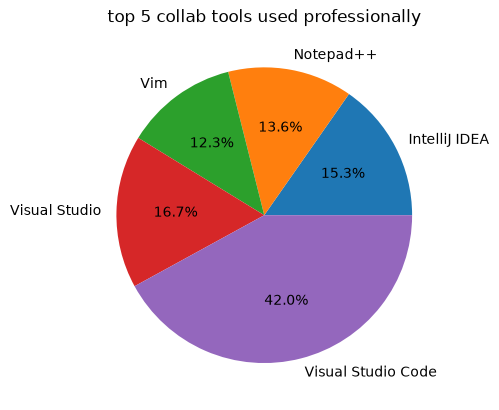

In [39]:
##Write your code here
#df['NEWCollabToolsHaveWorkedWith'].value_counts()
df_ncthww = df.copy()
df_ncthww['NEWCollabToolsHaveWorkedWith'] = df_ncthww['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_ncthww = df_ncthww.explode('NEWCollabToolsHaveWorkedWith')
df_ncthww['NEWCollabToolsHaveWorkedWith'] = df_ncthww['NEWCollabToolsHaveWorkedWith'].str.strip()
#df_ncthww['NEWCollabToolsHaveWorkedWith'].value_counts()
ncthww = df_ncthww.groupby(['NEWCollabToolsHaveWorkedWith']).size().reset_index(name = 'Frequency')
ncthww5 = df_ncthww['NEWCollabToolsHaveWorkedWith'].value_counts().head(5).index
ncthww = ncthww[ncthww['NEWCollabToolsHaveWorkedWith'].isin(ncthww5)]
plt.pie(ncthww['Frequency'] , labels = ncthww['NEWCollabToolsHaveWorkedWith'] , autopct = '%1.1f%%')
plt.title('top 5 collab tools used professionally')
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



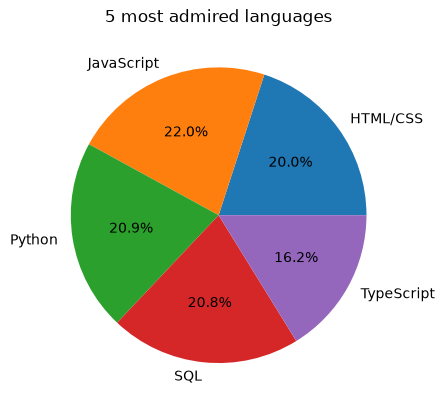

In [40]:
##Write your code here
df_lad = df.copy()
df_lad['LanguageAdmired'] = df_lad['LanguageAdmired'].str.split(';')
df_lad = df_lad.explode('LanguageAdmired')
df_lad['LanguageAdmired'] = df_lad['LanguageAdmired'].str.strip()
lad = df_lad.groupby(['LanguageAdmired']).size().reset_index(name = 'Frequency')
top_languages = df_lad['LanguageAdmired'].value_counts().head(5).index
lad = lad[lad['LanguageAdmired'].isin(top_languages)]
plt.pie(lad['Frequency'] , labels = lad['LanguageAdmired'] , autopct = '%1.1f%%')
plt.title('5 most admired languages')
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



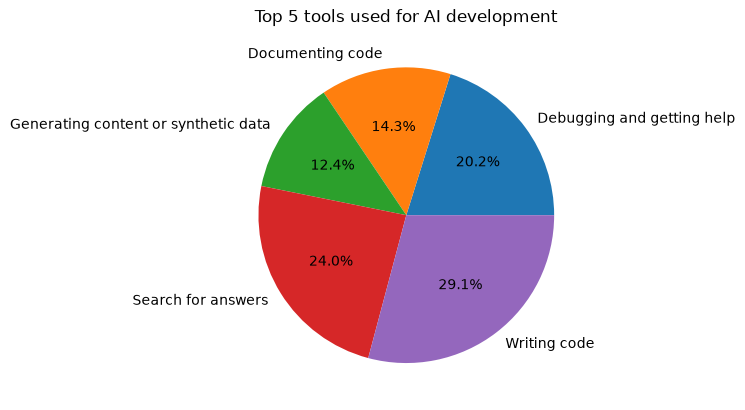

In [41]:
##Write your code here
#df['AIToolCurrently Using'].value_counts()
df_atc = df.copy()
df_atc['AIToolCurrently Using'] = df_atc['AIToolCurrently Using'].str.split(';')
df_atc = df_atc.explode('AIToolCurrently Using')
df_atc['AIToolCurrently Using'] = df_atc['AIToolCurrently Using'].str.strip()
atc = df_atc.groupby(['AIToolCurrently Using']).size().reset_index(name = 'Frequency')
atc5 = df_atc['AIToolCurrently Using'].value_counts().head(5).index
atc = atc[atc['AIToolCurrently Using'].isin(atc5)]
plt.pie(atc['Frequency'] , labels = atc['AIToolCurrently Using'] , autopct = '%1.1f%%')
plt.title('Top 5 tools used for AI development')
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



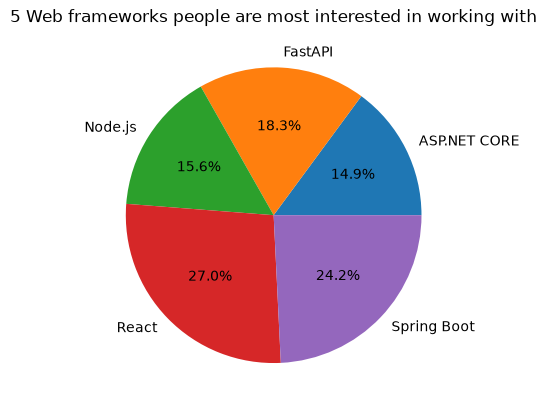

In [42]:
##Write your code here
#df['WebframeWantToWorkWith'].value_counts()
df_wfwww = df.copy()
df_wfwww['WebframeWantToWorkWith'] = df_wfwww['WebframeWantToWorkWith'].str.split(';')
df_wfwww = df_atc.explode('WebframeWantToWorkWith')
df_wfwww['WebframeWantToWorkWith'] = df_wfwww['WebframeWantToWorkWith'].str.strip()
wfwww = df_wfwww.groupby(['WebframeWantToWorkWith']).size().reset_index(name = 'Frequency')
wfwww5 = df_wfwww['WebframeWantToWorkWith'].value_counts().head(5).index
wfwww = wfwww[wfwww['WebframeWantToWorkWith'].isin(wfwww5)]
plt.pie(wfwww['Frequency'] , labels = wfwww['WebframeWantToWorkWith'] , autopct = '%1.1f%%')
plt.title('5 Web frameworks people are most interested in working with')
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



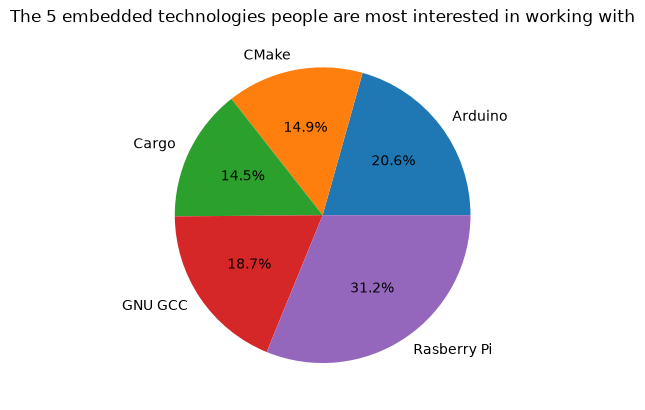

In [44]:
##Write your code here
#df['EmbeddedWantToWorkWith'].value_counts()
df_ewtww = df.copy()
df_ewtww['EmbeddedWantToWorkWith'] = df_ewtww['EmbeddedWantToWorkWith'].str.split(';')
df_ewtww = df_ewtww.explode('EmbeddedWantToWorkWith')
df_ewtww['EmbeddedWantToWorkWith'] = df_ewtww['EmbeddedWantToWorkWith'].str.strip()
ewtww = df_ewtww.groupby(['EmbeddedWantToWorkWith']).size().reset_index(name = 'Frequency')
ewtww5 = df_ewtww['EmbeddedWantToWorkWith'].value_counts().head(5).index
ewtww = ewtww[ewtww['EmbeddedWantToWorkWith'].isin(ewtww5)]
plt.pie(ewtww['Frequency'] , labels = ewtww['EmbeddedWantToWorkWith'] , autopct = '%1.1f%%')
plt.title('The 5 embedded technologies people are most interested in working with')
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
